<a href="https://colab.research.google.com/github/marie05919/Origami-Buddy/blob/main/ORIGAMI_CRANE_BUDDY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive #the images of my crane files are inported in
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/content/drive/MyDrive/origami crane folders

In [ ]:
!pip install fastai

In [ ]:
import fastai

In [ ]:
from fastai.metrics import accuracy, F1Score, Recall

training set 70% val and test = 15%

In [ ]:
from fastai.vision.all import *

path = Path('/content/drive/MyDrive/origami crane folders')
all_files = get_image_files(path)

set_seed(42)
splits = RandomSplitter(valid_pct=0.15, seed=42)(all_files)

In [ ]:
# shuffle your deck and deal it into two separate piles to be 85% and 15% 1st
train_val_pool, test_idx = RandomSplitter(valid_pct=0.315, seed=42)(all_files) # test set

# setting the 15% from the 85% aside which was the test set and the keeping the 85%
pool_files = all_files[train_val_pool]

# taking that 85% and then spliting it again to 15%
train_sub_idx, val_sub_idx = RandomSplitter(valid_pct=0.18, seed=42)(pool_files) # val

# spliting the train and val
train_idx = train_val_pool[train_sub_idx]
val_idx   = train_val_pool[val_sub_idx]

splits = (train_idx, val_idx, test_idx) # regrouping

train 40 test 40 val 20

In [ ]:
print("Train items:", len(splits[0]))
print("Val items:  ", len(splits[1]))
print("Test items: ", len(splits[2]))

Train items: 145
Val items:   31
Test items:  80


In [ ]:
## from fastai.callback.tracker import EarlyStoppingCallback, SaveModelCallback

In [ ]:
from fastai.vision.all import *

# 1. Define the DataBlock using a custom lambda function for your pre-calculated indices
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=lambda o: o,                # Pass items directly since all_files is already a list
    get_y=parent_label,
    splitter=lambda o: (train_idx, val_idx), # Uses your exact train and validation indices
    item_tfms=Resize(256),
    batch_tfms=aug_transforms()
)

# 2. Build training and validation dataloaders using all_files
dls = dblock.dataloaders(all_files)

# 3. Create your test dataloader using your test indices
test_files = all_files[test_idx]
test_dl = dls.test_dl(test_files, with_labels=True) # Keeps labels for final evaluation


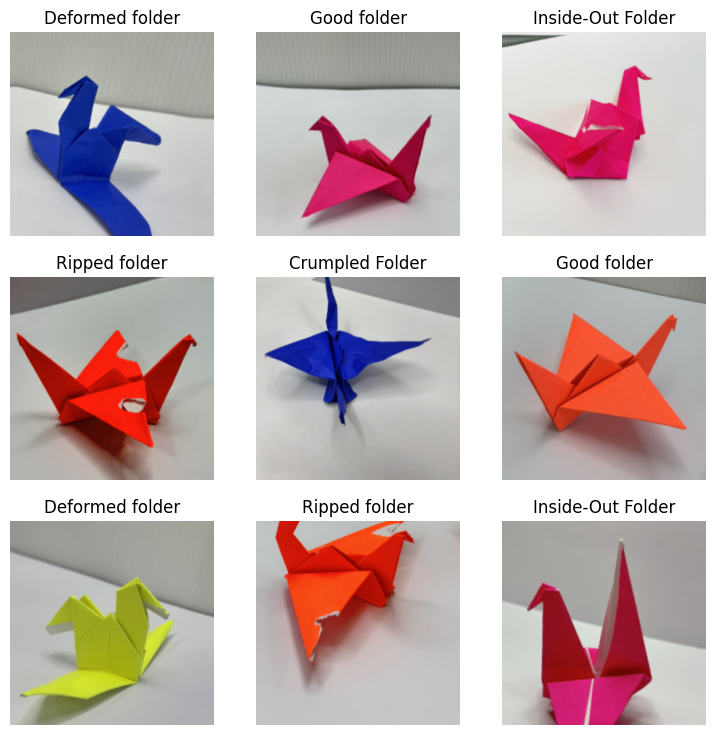

In [ ]:
dls.show_batch()

from fastai.metrics import accuracy, F1Score, Recall
from fastai.vision.all import *

In [ ]:
metrics_list = [accuracy, F1Score(average='macro'), Recall(average='macro')]
learn = vision_learner(dls, efficientnet_v2_s, metrics=metrics_list) #vision is for calling fastai test efficent or resnet or other models

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 169MB/s]


learn.fine_tune(75) VVVV

In [ ]:
#learn.fine_tune(
    #epochs=50, # Set a high upper bound
    ##cbs=[
        ##EarlyStoppingCallback(monitor='valid_loss', patience=6),
        #3SaveModelCallback(monitor='valid_loss', fname='best_model')
    ##]
)

epoch,train_loss,valid_loss,accuracy,f1_score,recall_score,time


In [ ]:
learn.fine_tune(50)

NameError: name 'learn' is not defined

In [ ]:
test_metrics = learn.validate(dl=test_dl)

print(f"Test Loss:     {test_metrics[0]:.4f}") # Aim for 30
print(f"Test Accuracy: {test_metrics[1]:.4f}") #Aim for High Recall (95 - 99) or 85 up
print(f"Test F1 Score: {test_metrics[2]:.4f}") # Aim for 80
print(f"Test Recall:   {test_metrics[3]:.4f}") # Aim for 85

In [ ]:
# Create an interpretation object focused strictly on your test set
interp = ClassificationInterpretation.from_learner(learn, dl=test_dl)

interp.plot_confusion_matrix() # plotting the matrix


In [ ]:
interp.plot_top_losses(k=9, nrows=3) # extra: display what it failed to classify(TOP 3)

In [ ]:
# Saves the entire model for inference to 'export.pkl'
learn.export('export.pkl')

In [ ]:
from fastai.learner import load_learner
learn_inf = load_learner('export.pkl')

In [ ]:
img_path = '/content/drive/MyDrive/origami crane folders/Crumpled Folder/crumpled28.jpg'

# 3. Get the prediction
# fastai handles opening the image path automatically
pred, pred_idx, probs = learn_inf.predict(img_path)

# 4. Display the results
print(f"Prediction: {pred}")
print(f"Class Index: {pred_idx}")
print(f"Probability: {probs[pred_idx]:.4f}")